In [21]:
from pydantic import BaseModel

import cohere

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage, convert_to_openai_messages, HumanMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from pydantic import Field
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

### Agent Graph with Loopback from Tools (ReAct Agent)

In [22]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


@traceable(
    name="rerank_data",
    run_type="tool"
)
def rerank_data(query, context, top_k=5):

    cohere_client = cohere.ClientV2()

    response = cohere_client.rerank(
        model="rerank-v4.0-pro",
        query=query,
        documents=context["retrieved_context"],
        top_n=top_k
    )

    order = [result.index for result in response.results]

    return {
        "retrieved_context_ids": [context["retrieved_context_ids"][i] for i in order],
        "retrieved_context": [context["retrieved_context"][i] for i in order],
        "similarity_scores": [context["similarity_scores"][i] for i in order],
        "retrieved_context_ratings": [context["retrieved_context_ratings"][i] for i in order]
    }


@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:

    """Get the top k context, each representing an inventory item for a given query.
    
    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more
    
    Returns:
        A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.
    """

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = retrieve_data(
        query,
        qdrant_client,
        k=20
    )

    retrieved_context = rerank_data(query, retrieved_context, top_k=top_k)
    formatted_context = process_context(retrieved_context)

    return formatted_context

### State and Pydantic Models for Structured Outputs

In [23]:
class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Answer to the question")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: list[RAGUsedContext] = []


In [24]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    
    prompt_template = """You are a shopping assistant that answers customer questions about products currently in stock.

## Instructions

- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they're interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
"""

    template = Template(prompt_template)

    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [get_formatted_item_context, FinalResponse],
        tool_choice="any"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""
    references = []

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                references.extend(tool_call.get("args").get("references"))

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer,
        "references": references
    }

In [25]:
def tool_router(state: State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

### User Intent Router Node

In [26]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the users question is not relevant to the products.")

In [27]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information
"""

    template = Template(prompt_template)

    prompt = template.render()

    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [28]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

### Grapg Construction

In [29]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

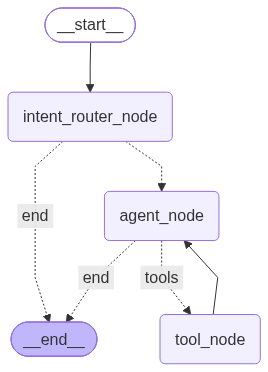

In [30]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker?")]
}

In [36]:
result = graph.invoke(initial_state)

In [37]:
result

{'messages': [HumanMessage(content='Can I get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"tablet for kid", "top_k":5}', 'call_id': 'call_qgdZPK9WMxCr7CJ3IZBRCfv2', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0dae68ccf1c4841f006a6146b7d5ec819aaf6188166fb6ba8d', 'status': 'completed'}, {'arguments': '{"query":"watch for adult smartwatch", "top_k":5}', 'call_id': 'call_aCcD4ByrSboqopqfMs6sZBNC', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0dae68ccf1c4841f006a6146b7d5fc819abfe9921058d12d15', 'status': 'completed'}, {'arguments': '{"query":"laptop for home use wife", "top_k":5}', 'call_id': 'call_Q1pWxt4y3q5buSgokqjD3yIb', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0dae68ccf1c4841f006a6146b7d604819a94e339afb3542e97', 'status': 'completed'}, {'arguments': '{"query":"waterpro

In [39]:
print(result["answer"])

Yes — I found available products for all four items:

**Tablet for your kid**
- Kids-focused 7-inch tablets with parental controls and educational apps preinstalled.
- Options include Android 10 or Android 12 Go, Wi‑Fi, expandable storage, and kid-proof cases.
- Best matches:
  - B0BGHBL86V: 1GB RAM, 32GB storage, 2MP rear camera, expandable to 256GB, ages 3–14.
  - B0C7DCS2KW: 2GB RAM, 32GB storage, 1080p screen, expandable to 128GB, Android 12 Go.

**Watch for you**
- Smart watches with Bluetooth calling and waterproof designs.
- Options include heart rate, blood pressure, sleep tracking, and sports modes.
- Best matches:
  - B09QKT279R: calls, waterproof, heart rate and blood pressure monitoring.
  - B0BYRXT52V: Alexa built-in, IP68 waterproof, calls, 100+ sports modes.

**Laptop for your wife**
- Lightweight Windows or Chrome OS laptops suitable for home, work, or school use.
- Options include 11.6-inch, 14-inch, 15.6-inch, and 17.3-inch models.
- Best matches:
  - B0C9ZWCZ99: HP 1

In [40]:
initial_state = {
    "messages": [HumanMessage(content="What is the weather today?")]
}

In [41]:
result = graph.invoke(initial_state)

In [42]:
result

{'messages': [HumanMessage(content='What is the weather today?', additional_kwargs={}, response_metadata={})],
 'question_relevant': False,
 'answer': 'This question is not related to products, inventory, or purchasing.'}